# **Analysis of trained network**

In [1]:
#Clone the GitHub repository

!git clone https://github.com/jgrk28/kalnet.git
%cd kalnet
%pip install -e .
%cd paper_pytorch

Cloning into 'kalnet'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (108/108), done.
Receiving objects: 100% (118/118), 2.62 MiB | 10.70 MiB/s, done.
remote: Total 118 (delta 63), reused 30 (delta 8), pack-reused 0 (from 0)
Resolving deltas: 100% (63/63), done.
/content/kalnet
Obtaining file:///content/kalnet
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 129.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 125.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
#Imports

import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path

## RNN with batch_size = 10

### **Data collection**
Collects the hidden layer activity and generates two splits of the data (train and test) for subsequent analysis

In [5]:
from task import KalmanFilteringTask
from model import KalmanRNN


def collect(task: KalmanFilteringTask, net: KalmanRNN, n_trials: int, device: str = "cpu"):
    """Collect hidden states + ground truth for n_trials, in chunks of task.batch_size."""
    net.eval()
    all_r_hid, all_s, all_g, all_mu, all_sigma_sq, all_s_hat = [], [], [], [], [], []

    n_collected = 0
    with torch.no_grad():
        while n_collected < n_trials:
            batch = task.sample(include_internals=True)

            # Explicit NumPy -> torch conversion, since batch.* are np.ndarray here
            x = torch.from_numpy(batch.input).to(device)
            s = torch.from_numpy(batch.target[:, :, 0]).to(device)
            g = torch.from_numpy(batch.internals.gain[:, :, 0]).to(device)
            mu = torch.from_numpy(batch.opt_mean[:, :, 0]).to(device)
            sigma_sq = torch.from_numpy(batch.internals.opt_var[:, :, 0]).to(device)

            y, hidden = net(x, return_hidden=True)
            s_hat = y[:, :, 0]  # already a torch.Tensor -- net's own output

            all_r_hid.append(hidden.cpu())
            all_s.append(s.cpu())
            all_g.append(g.cpu())
            all_mu.append(mu.cpu())
            all_sigma_sq.append(sigma_sq.cpu())
            all_s_hat.append(s_hat.cpu())

            n_collected += batch.input.shape[0]  # = task.batch_size, each call

    return {
        "r_hid": torch.cat(all_r_hid, dim=0)[:n_trials],
        "s": torch.cat(all_s, dim=0)[:n_trials],
        "g": torch.cat(all_g, dim=0)[:n_trials],
        "mu": torch.cat(all_mu, dim=0)[:n_trials],
        "sigma_sq": torch.cat(all_sigma_sq, dim=0)[:n_trials],
        "s_hat": torch.cat(all_s_hat, dim=0)[:n_trials],
    }


In [6]:
device = "cpu"
checkpoint = torch.load("networks/kf_allgains_def.pt", map_location=device, weights_only=False) #Make sure the path points to the network you want to analyze
net = KalmanRNN(
    n_in=checkpoint["config"]["n_in"],
    n_hid=checkpoint["config"]["n_hid"],
    n_out=1,
).to(device)
net.load_state_dict(checkpoint["state_dict"])
print("Loaded trained network.")

train_task = KalmanFilteringTask(batch_size=500, tr_cond="all_gains", seed=1000)
test_task = KalmanFilteringTask(batch_size=500, tr_cond="all_gains", seed=2000)

print("Collecting training set (normal trials)...")
train_data = collect(train_task, net, n_trials=5000, device=device)

print("Collecting held-out test set (normal trials)...")
test_data = collect(test_task, net, n_trials=2000, device=device)

torch.save({"train": train_data, "test": test_data}, "kf_dataset.pt")
print("Saved kf_dataset.pt")
print(f"  train:    r_hid {train_data['r_hid'].shape}")
print(f"  test:     r_hid {test_data['r_hid'].shape}")

Loaded trained network.
Saved kf_dataset.pt
  train:    r_hid torch.Size([5000, 25, 200])
  test:     r_hid torch.Size([2000, 25, 200])


### Fit a linear decoder to the activity of the hidden layer and the ground truth uncertainty from the Kalman task

Equation (7) and (8) from the paper

Pooled samples: train=125000, test=50000

1. LINEAR DECODING: sigma_sq vs. precision (1/sigma_sq)
  decode sigma_sq                R^2 = 0.8588
  decode precision (1/sigma_sq)  R^2 = 0.9103
  shuffled-label control         R^2 = -0.0021 +/- 0.0026  (range: [-0.0061, 0.0007])

  --> precision decodes better (0.9103 vs 0.8588)

2. SPECIFIC-STATISTIC CORRELATIONS (mean activity, sparsity/kurtosis)
  corr(mean activity, sigma_sq):  r=+0.3357  p=0.00e+00
  corr(kurtosis,      sigma_sq):  r=-0.6554  p=0.00e+00

  --> SPARSITY code looks dominant


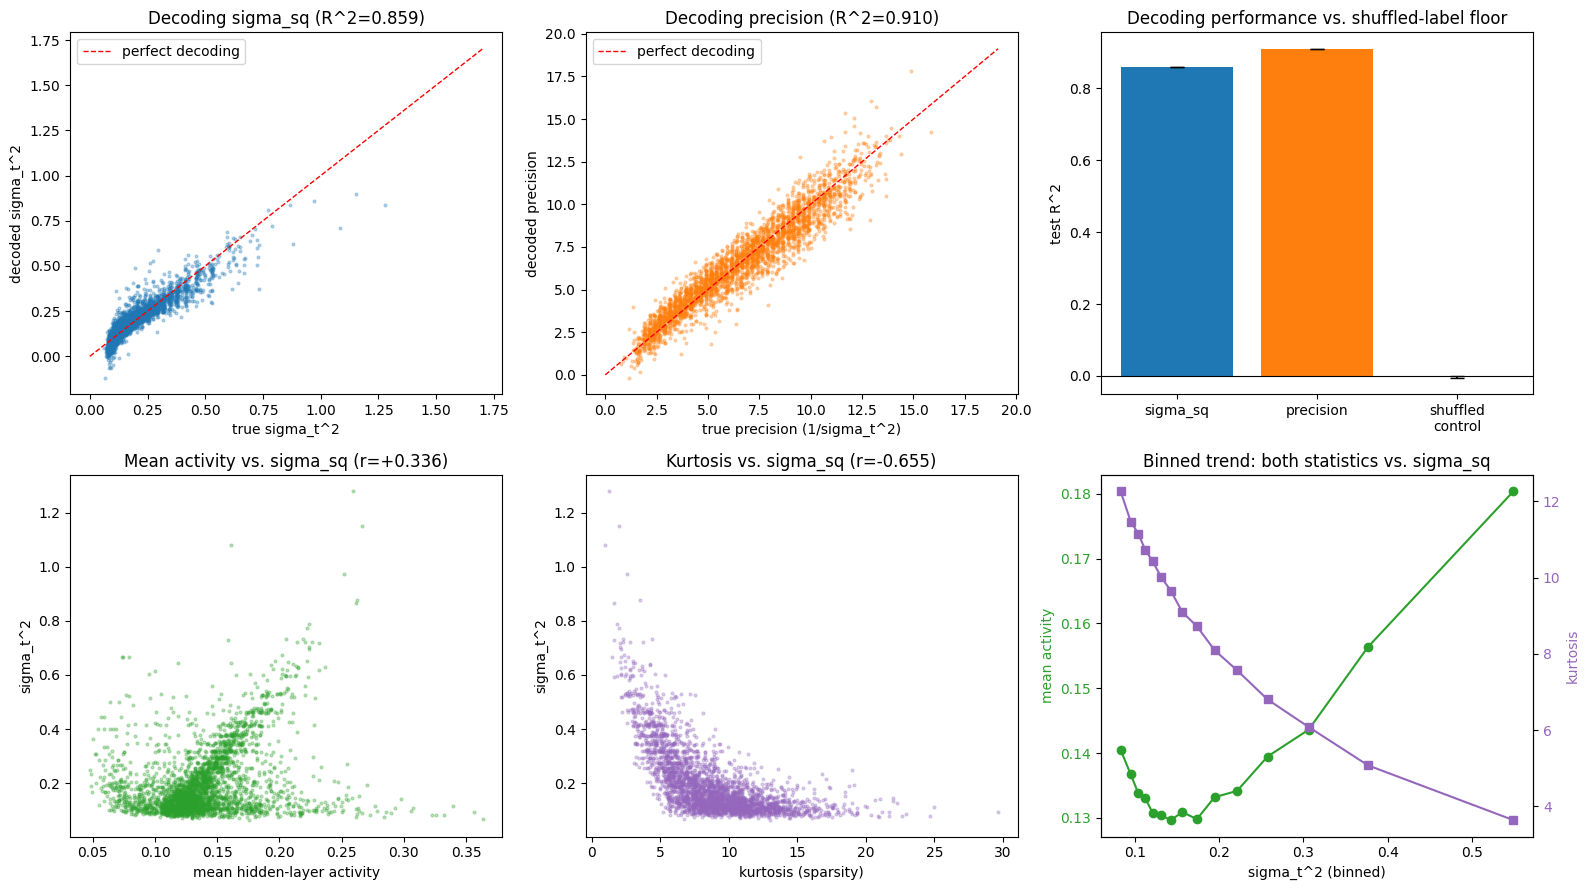


Saved decode_results.png


In [11]:
from decode import lin_decoder
data = lin_decoder("kf_dataset.pt")

## RNN with batch_size = 100

In [14]:
from task_vec import KalmanFilteringTask
def collect(task: KalmanFilteringTask, net: KalmanRNN, n_trials: int, device: str = "cpu"):
    """Collect hidden states + ground truth for n_trials, in chunks of task.batch_size.
    task should already be constructed with the batch_size/tr_cond/seed """

    net.eval()
    all_r_hid, all_s, all_g, all_mu, all_sigma_sq, all_s_hat = [], [], [], [], [], []

    n_collected = 0
    with torch.no_grad():
        while n_collected < n_trials:
            batch = task.sample(include_internals=True)

            y, hidden = net(batch.input.to(device), return_hidden=True)
            # squeeze away the trailing singleton feature dim to match this
            # project's (n_trials, T) convention throughout
            s_hat = y[:, :, 0]
            s = batch.target[:, :, 0].to(device)
            g = batch.internals.gain[:, :, 0].to(device)
            mu = batch.opt_mean[:, :, 0].to(device)
            sigma_sq = batch.internals.opt_var[:, :, 0].to(device)

            all_r_hid.append(hidden.cpu())
            all_s.append(s.cpu())
            all_g.append(g.cpu())
            all_mu.append(mu.cpu())
            all_sigma_sq.append(sigma_sq.cpu())
            all_s_hat.append(s_hat.cpu())

            n_collected += batch.input.shape[0]  # = task.batch_size, each call

    return {
        "r_hid": torch.cat(all_r_hid, dim=0)[:n_trials],
        "s": torch.cat(all_s, dim=0)[:n_trials],
        "g": torch.cat(all_g, dim=0)[:n_trials],
        "mu": torch.cat(all_mu, dim=0)[:n_trials],
        "sigma_sq": torch.cat(all_sigma_sq, dim=0)[:n_trials],
        "s_hat": torch.cat(all_s_hat, dim=0)[:n_trials],
    }

In [16]:
device = "cpu"
checkpoint = torch.load("networks/kf_allgains_batch100.pt", map_location=device, weights_only=False)
net = KalmanRNN(
    n_in=checkpoint["config"]["n_in"],
    n_hid=checkpoint["config"]["n_hid"],
    n_out=1,
).to(device)
net.load_state_dict(checkpoint["state_dict"])
print("Loaded trained network.")

# One KalmanFilteringTask instance per split, each with its own widely-separated
# seed (matching the original collect_data.py's non-overlapping-draws guarantee),
# and each fixed to a convenient batch_size for chunked collection.
train_task = KalmanFilteringTask(batch_size=500, tr_cond="all_gains", seed=1000, device=device)
test_task = KalmanFilteringTask(batch_size=500, tr_cond="all_gains", seed=2000, device=device)
print("Collecting training set (normal trials)...")
train_data = collect(train_task, net, n_trials=5000, device=device)

print("Collecting held-out test set (normal trials)...")
test_data = collect(test_task, net, n_trials=2000, device=device)

torch.save(
    {"train": train_data, "test": test_data},
    "kf_dataset_100.pt",
)
print("Saved kf_dataset_100.pt")
print(f"  train:    r_hid {train_data['r_hid'].shape}")
print(f"  test:     r_hid {test_data['r_hid'].shape}")

Loaded trained network.
Saved kf_dataset_100.pt
  train:    r_hid torch.Size([5000, 25, 200])
  test:     r_hid torch.Size([2000, 25, 200])


### Fit a linear decoder to the activity of the hidden layer and the ground truth uncertainty from the Kalman task


Pooled samples: train=125000, test=50000

1. LINEAR DECODING: sigma_sq vs. precision (1/sigma_sq)
  decode sigma_sq                R^2 = 0.9546
  decode precision (1/sigma_sq)  R^2 = 0.9860
  shuffled-label control         R^2 = 0.0019 +/- 0.0056  (range: [-0.0069, 0.0070])

  --> precision decodes better (0.9860 vs 0.9546)

2. SPECIFIC-STATISTIC CORRELATIONS (mean activity, sparsity/kurtosis)
  corr(mean activity, sigma_sq):  r=+0.0036  p=4.22e-01
  corr(kurtosis,      sigma_sq):  r=-0.6567  p=0.00e+00

  --> SPARSITY code looks dominant


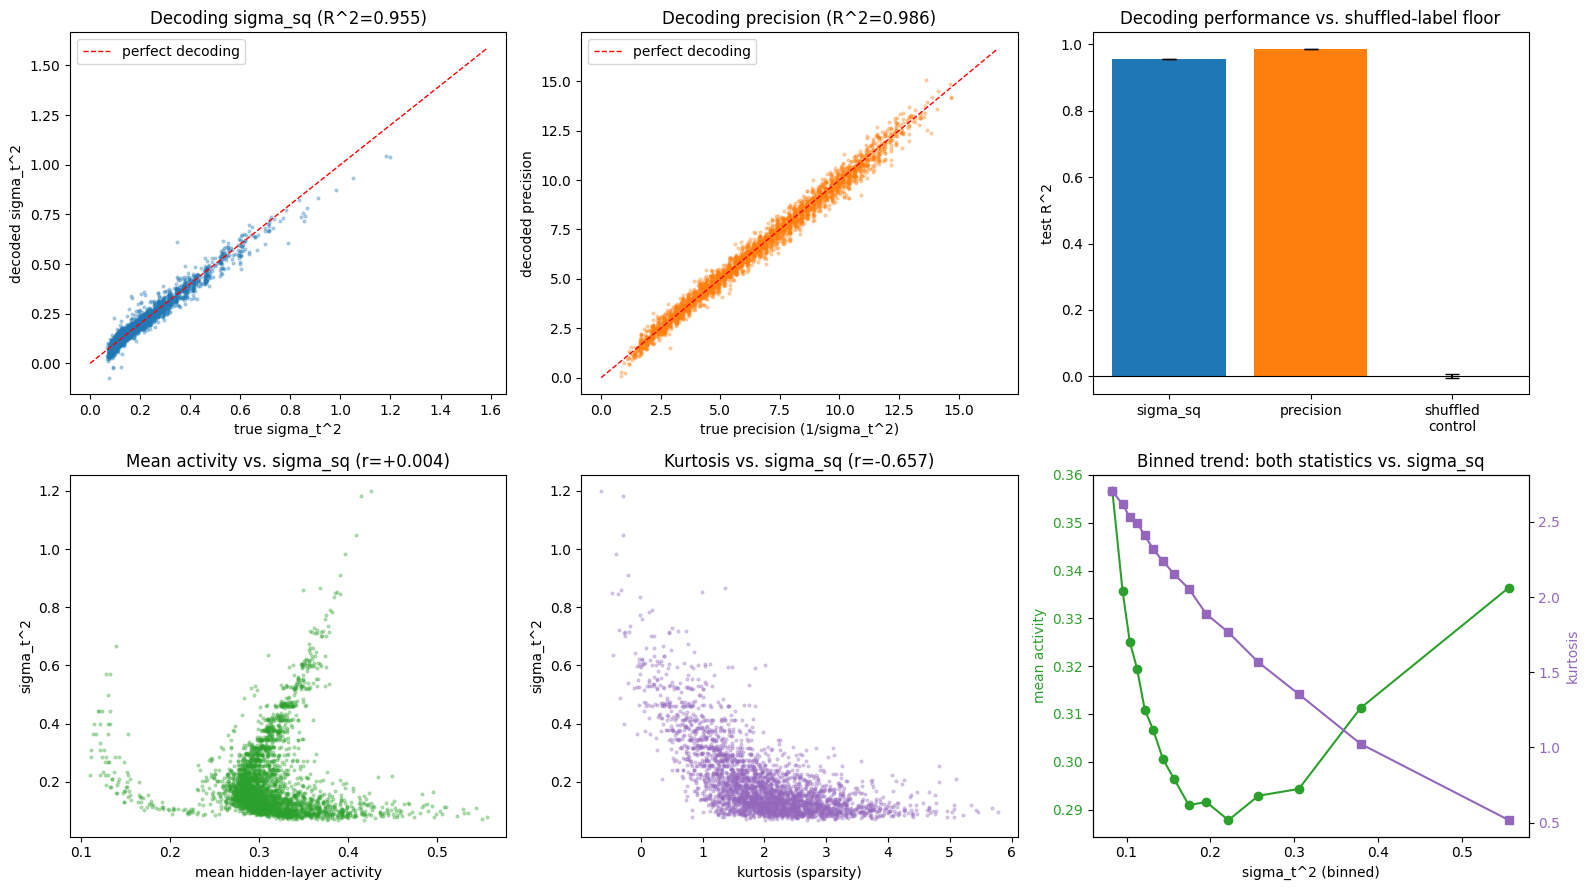


Saved decode_results.png


In [18]:
data = lin_decoder("kf_dataset_100.pt")